## Importing Required Libraries 

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

## Load the data

In [128]:
data_path = Path('../data/loan_data.csv')
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: (45000, 14)

First few rows:


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## Statistical Analysis

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [130]:
df.columns.tolist()

['person_age',
 'person_gender',
 'person_education',
 'person_income',
 'person_emp_exp',
 'person_home_ownership',
 'loan_amnt',
 'loan_intent',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'credit_score',
 'previous_loan_defaults_on_file',
 'loan_status']

In [131]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.209400,0.406885,0.00,0.00,0.00,0.00,1.00


In [132]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [133]:
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
print(missing_data)
if len(missing_data) == 0:
    print("\nNo missing values found in the dataset!")
else:
    print("\nMissing Values Summary:")
    print(missing_data.to_string(index=False))

Empty DataFrame
Columns: [Column, Missing_Count, Missing_Percentage]
Index: []

No missing values found in the dataset!


In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

## Exploratory Data Analysis

<Axes: ylabel='count'>

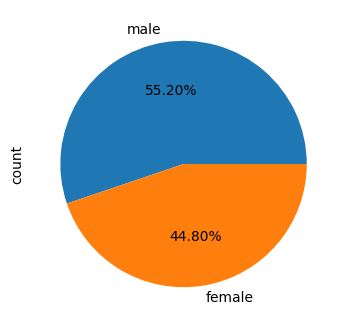

In [135]:
plt.figure(figsize =(4,4))
df['person_gender'].value_counts().plot(kind ='pie',autopct = '%0.2f%%')

<Axes: ylabel='count'>

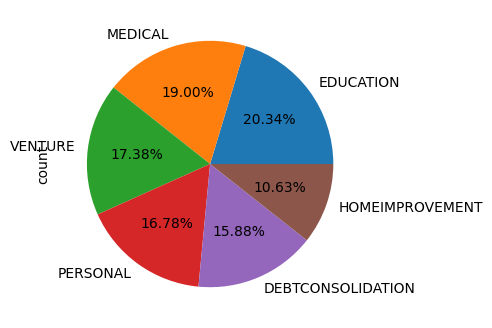

In [136]:
plt.figure(figsize =(4,4))
df['loan_intent'].value_counts().plot(kind ='pie',autopct = '%0.2f%%')

<Axes: ylabel='count'>

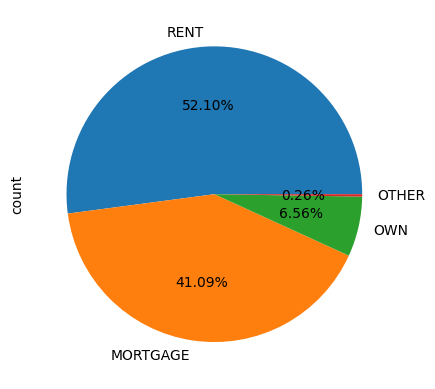

In [137]:
df['person_home_ownership'].value_counts().plot(kind ='pie',autopct = '%0.2f%%')

<Axes: ylabel='count'>

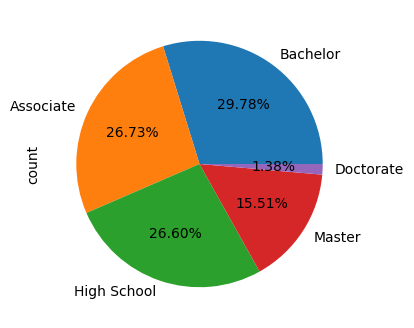

In [138]:
plt.figure(figsize =(4,4))
df['person_education'].value_counts().plot(kind ='pie',autopct = '%0.2f%%')

In [139]:
continuous_cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'person_emp_exp']
categorical_cols = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file', 'loan_status']

Text(0, 0.5, '')

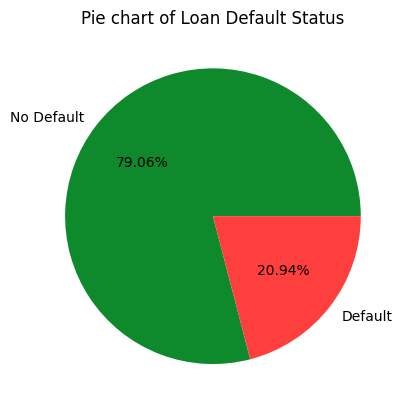

In [140]:
df['loan_status'].value_counts().plot.pie(labels=['No Default', 'Default'], autopct='%.2f%%', colors=["#0E8A2D",  "#ff3e3e"])
plt.title('Pie chart of Loan Default Status')
plt.ylabel('')

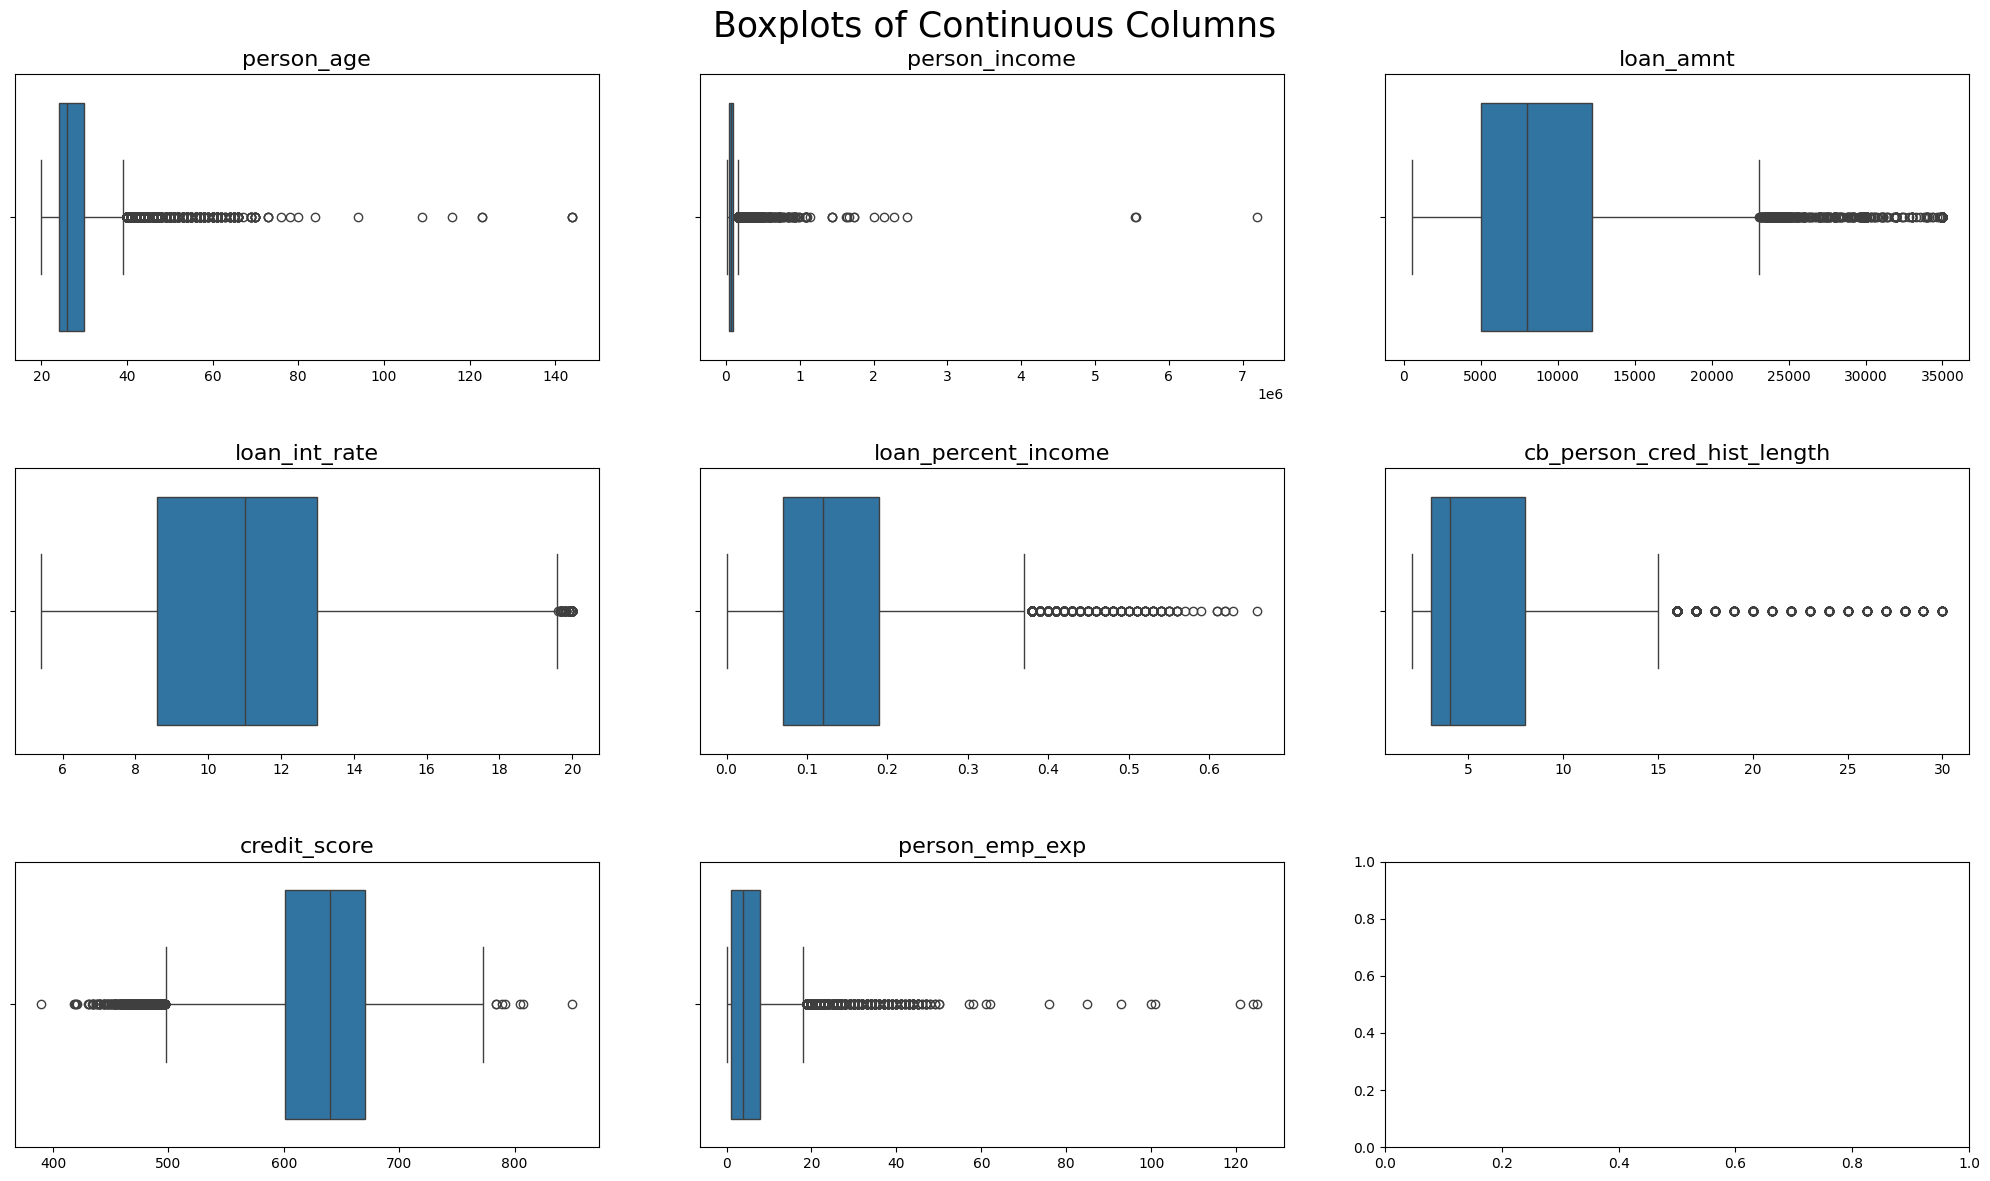

In [141]:
import math
import os
fig, ax = plt.subplots(nrows=3, ncols=math.ceil(len(df[continuous_cols].columns) / 3), figsize=(20, 12))
ax = ax.flatten()
fig.suptitle('Boxplots of Continuous Columns', fontsize=25)
for i, col in enumerate(df[continuous_cols].columns):
    sns.boxplot(data=df[continuous_cols], x=col, ax=ax[i])
    ax[i].set_title(col, fontsize=16)
    ax[i].set_xlabel('')

plt.tight_layout(h_pad=3, w_pad=5)
plt.show()

From the boxplots, it was observed that the `person_age` and `person_emp_exp` columns contained values as high as 140 and 120 respectively, which are not realistic. Therefore, the extreme values were replaced with the median of their respective columns.

In [142]:
df.loc[(df['person_age']>85) | (df['person_emp_exp'] > 65)]

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
81,144.0,male,Bachelor,300616.0,125,RENT,4800.0,VENTURE,13.57,0.02,3.0,789,No,0
183,144.0,male,Associate,241424.0,121,MORTGAGE,6000.0,EDUCATION,11.86,0.02,2.0,807,No,0
575,123.0,female,High School,97140.0,101,RENT,20400.0,EDUCATION,10.25,0.21,3.0,805,Yes,0
747,123.0,male,Bachelor,94723.0,100,RENT,20000.0,VENTURE,11.01,0.21,4.0,714,Yes,0
32297,144.0,female,Associate,7200766.0,124,MORTGAGE,5000.0,PERSONAL,12.73,0.00,25.0,850,No,0
32416,94.0,male,High School,29738.0,76,RENT,6500.0,MEDICAL,11.01,0.22,27.0,773,No,0
37930,116.0,male,Bachelor,5545545.0,93,MORTGAGE,3823.0,VENTURE,12.15,0.00,24.0,708,No,0
38113,109.0,male,High School,5556399.0,85,MORTGAGE,6195.0,VENTURE,12.58,0.00,22.0,792,No,0


In [143]:
df['person_age']= df['person_age'].apply(lambda x: df['person_age'].median() if x > 85 else x)
df['person_emp_exp']= df['person_emp_exp'].apply(lambda x: df['person_emp_exp'].median() if x > 65 else x)

## Categorical wise count plot

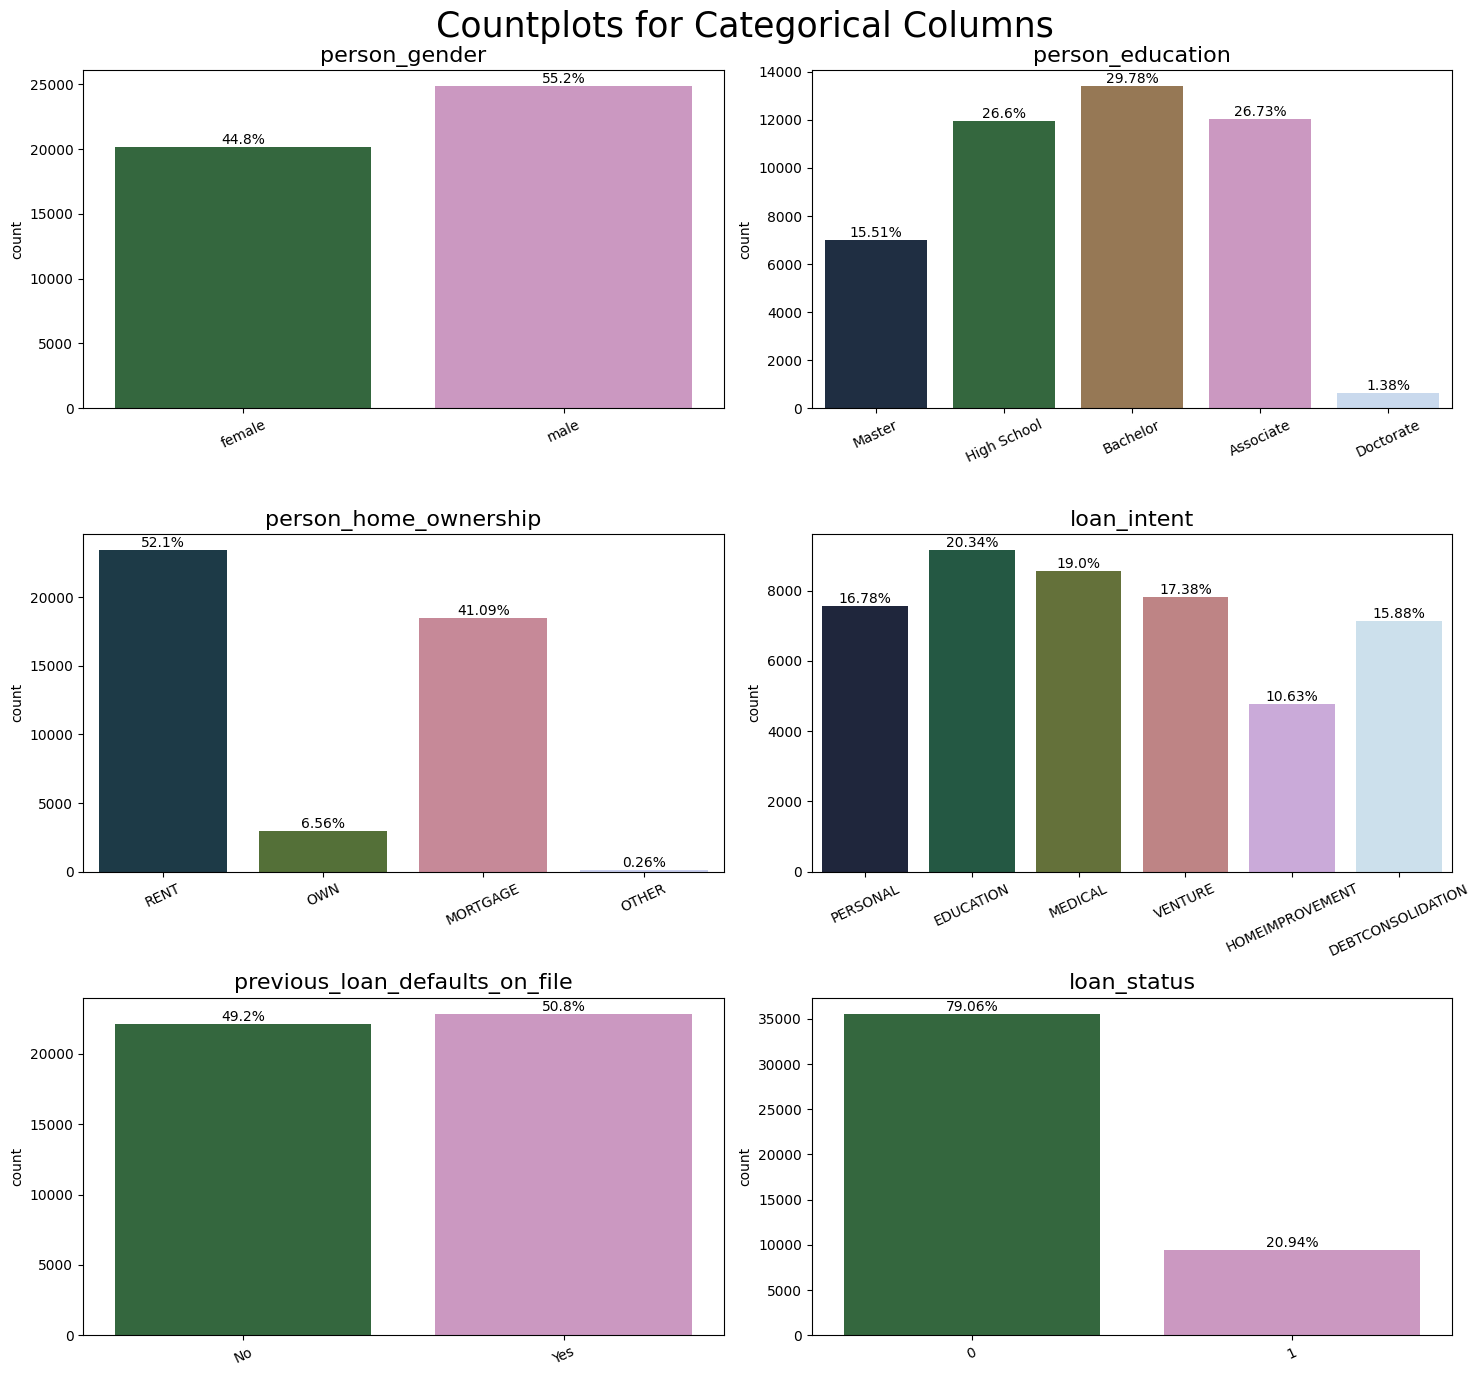

In [144]:
fig, ax = plt.subplots(nrows=3, ncols=math.ceil(len(df[categorical_cols].columns)/3), figsize=(15, 14))
ax = ax.flatten()
total = len(df)
fig.suptitle('Countplots for Categorical Columns', fontsize=25)
for i, col in enumerate(df[categorical_cols].columns):
  axis = sns.countplot(df[categorical_cols], x=col, ax=ax[i], palette='cubehelix')
  plt.xticks(rotation=45)
  axis.set_title(col, fontsize=16)
  axis.set_xlabel('')
  axis.tick_params(axis= 'x', rotation=25)
  
  for p in axis.patches:
      count = p.get_height()
      percentage = f'{round((100 * count / total), 2)}%'     
      
      axis.text(p.get_x() + p.get_width() / 2, count + 0.05, percentage, ha='center', va='bottom', fontsize=10)

plt.tight_layout();

for j in range(i + 1, len(ax)):
    fig.delaxes(ax[j])


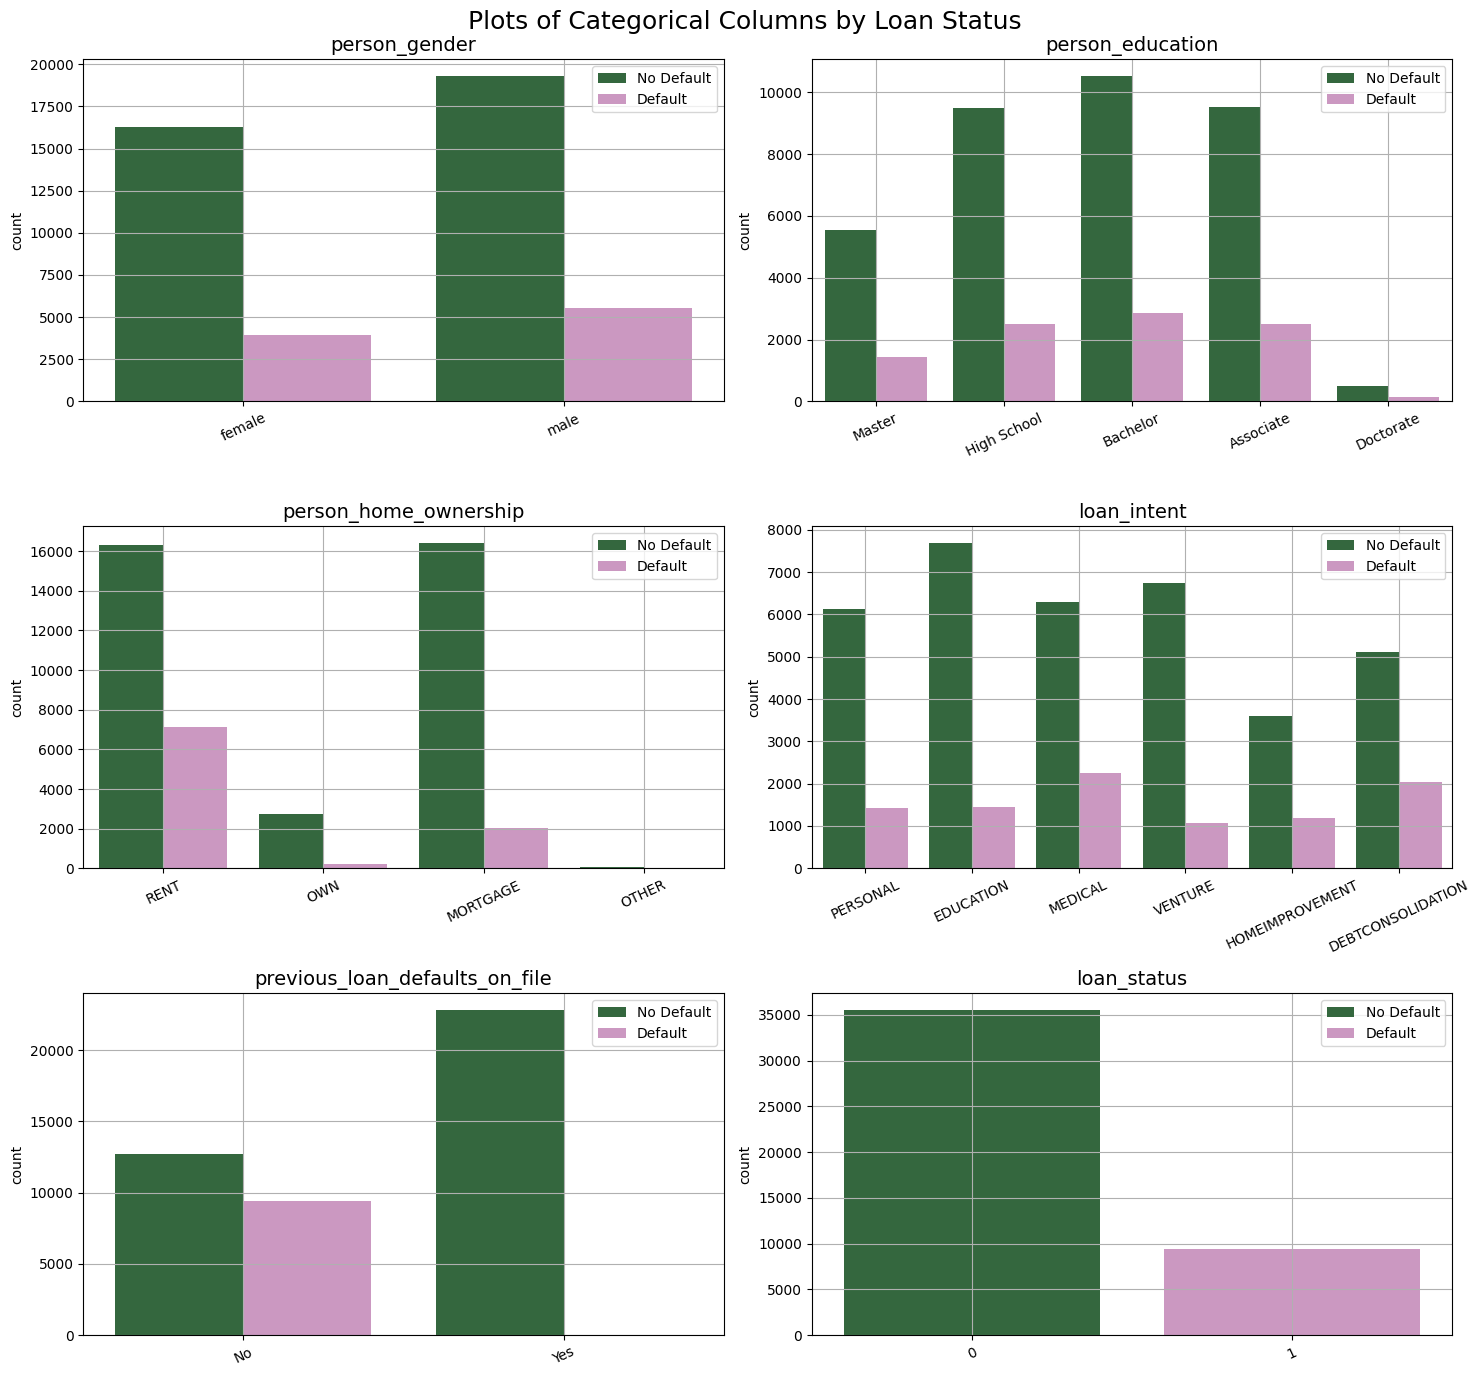

In [145]:
fig, ax = plt.subplots(nrows=3, ncols=math.ceil(len(df[categorical_cols].columns)/3), figsize=(15, 14))
ax = ax.flatten()
fig.suptitle('Plots of Categorical Columns by Loan Status', fontsize=18)
# plt.tight_layout()
for i, col in enumerate(df[categorical_cols].columns):
  axis = sns.countplot(df[categorical_cols], x=col, ax=ax[i], hue='loan_status', palette='cubehelix')
  plt.xticks(rotation=45)
  axis.grid(True)
  axis.legend(['No Default', 'Default']);
  axis.set_title(col, fontsize=14)
  axis.set_xlabel('')
  axis.tick_params(axis= 'x', rotation=25)
  
plt.tight_layout()

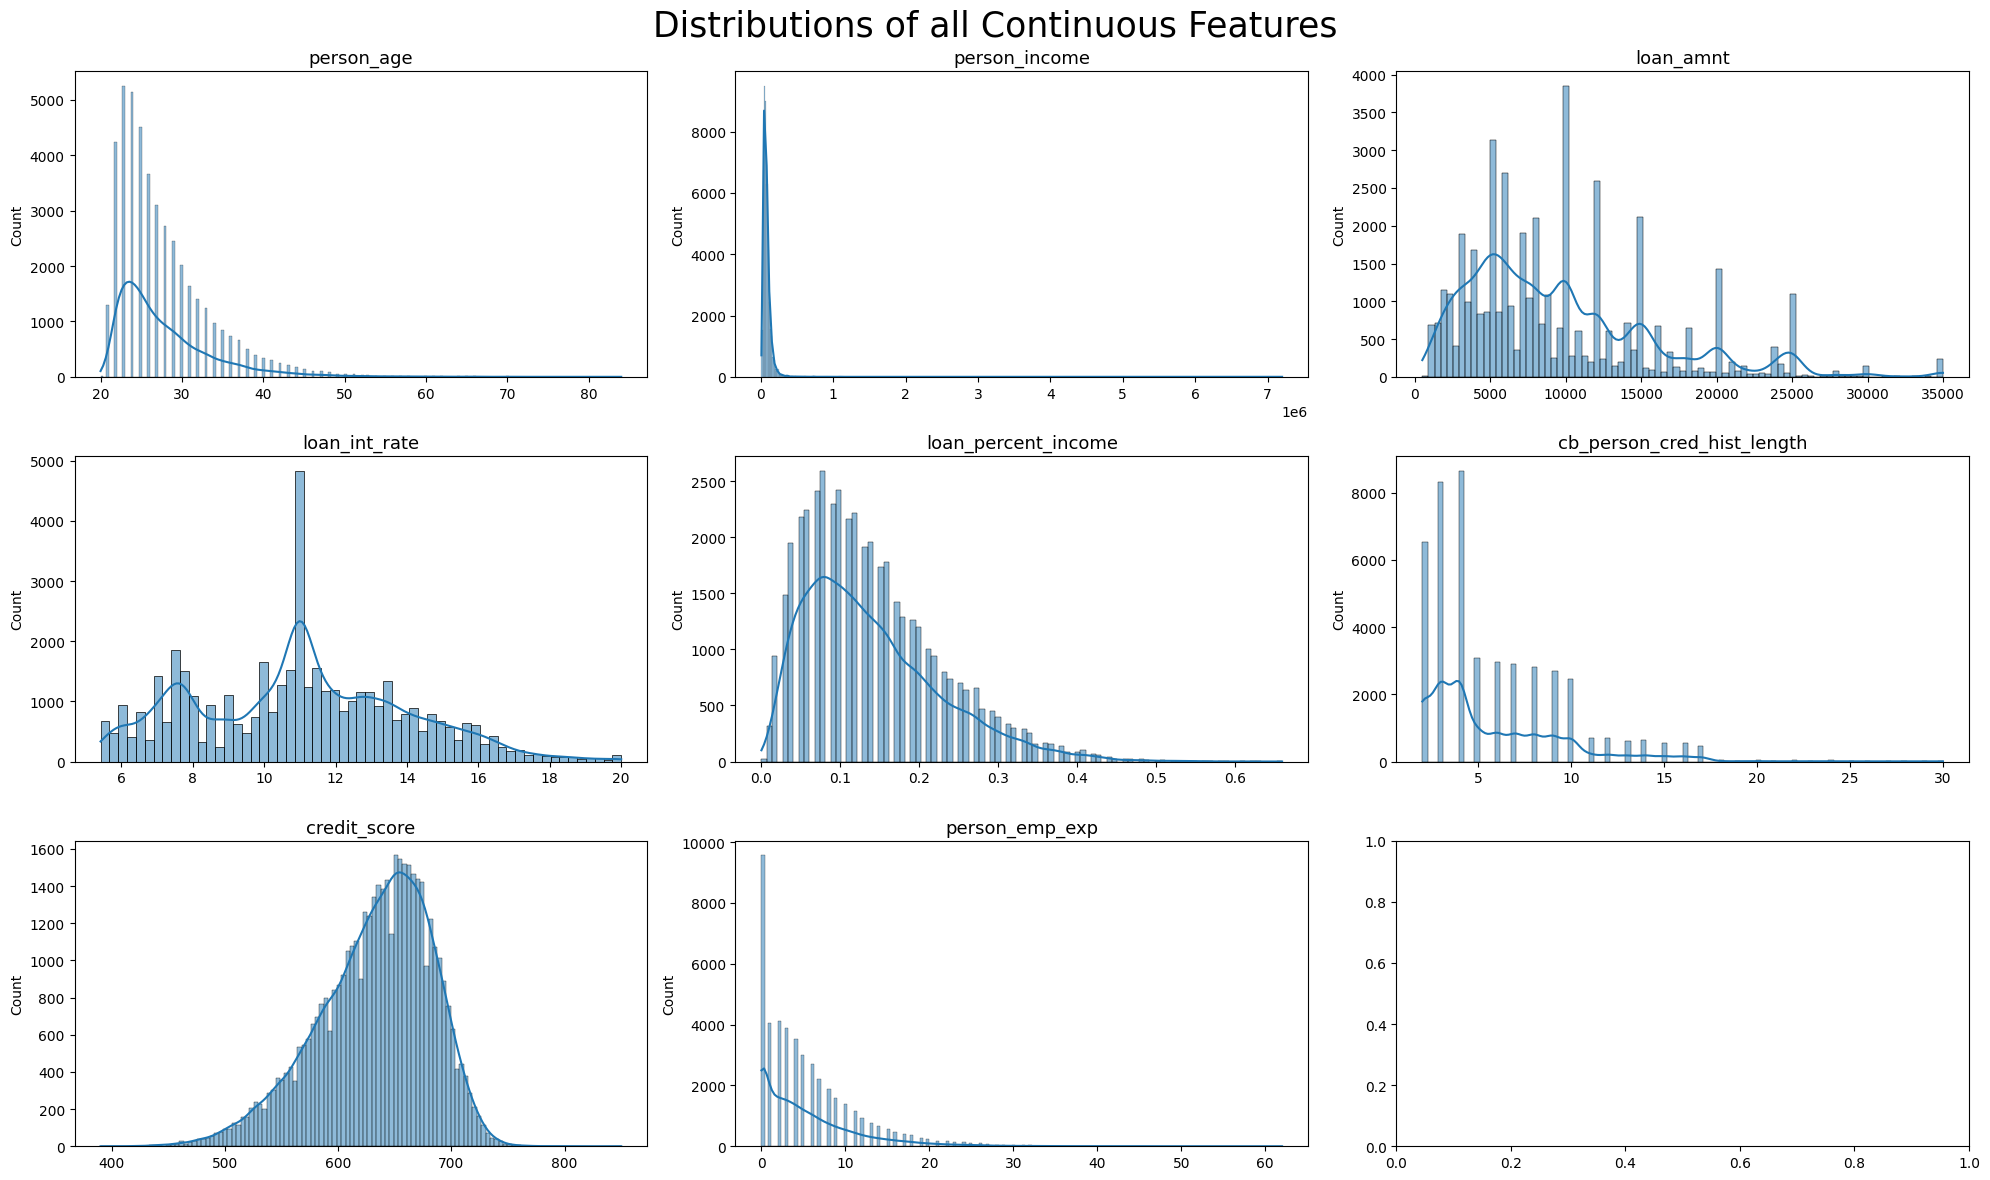

In [146]:
fig, ax = plt.subplots(nrows=3, ncols=math.ceil(len(df[continuous_cols].columns) / 3), figsize=(20, 12))
ax = ax.flatten()
fig.suptitle('Distributions of all Continuous Features', fontsize=25)
for i, col in enumerate(df[continuous_cols].columns):
    sns.histplot(data=df[continuous_cols], x=col, ax=ax[i], kde=True)
    ax[i].set_title(col, fontsize=13)
    ax[i].set_xlabel('')
plt.tight_layout()
plt.show()


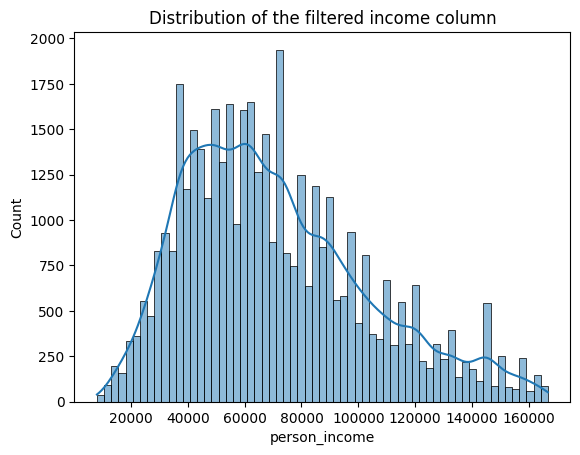

In [147]:
# filtering our income columns for incomes less than the 95th percentile for better visualiation
filtered_income = df.loc[df['person_income'] < df['person_income'].quantile(.95)]
sns.histplot(filtered_income['person_income'], kde=True)
plt.title('Distribution of the filtered income column')
plt.show()

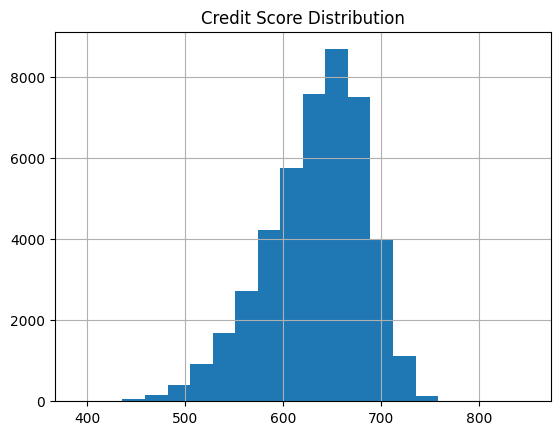

In [148]:
## Majority of credit scores are around 650
df['credit_score'].hist(bins=20)
plt.title('Credit Score Distribution');
plt.show()

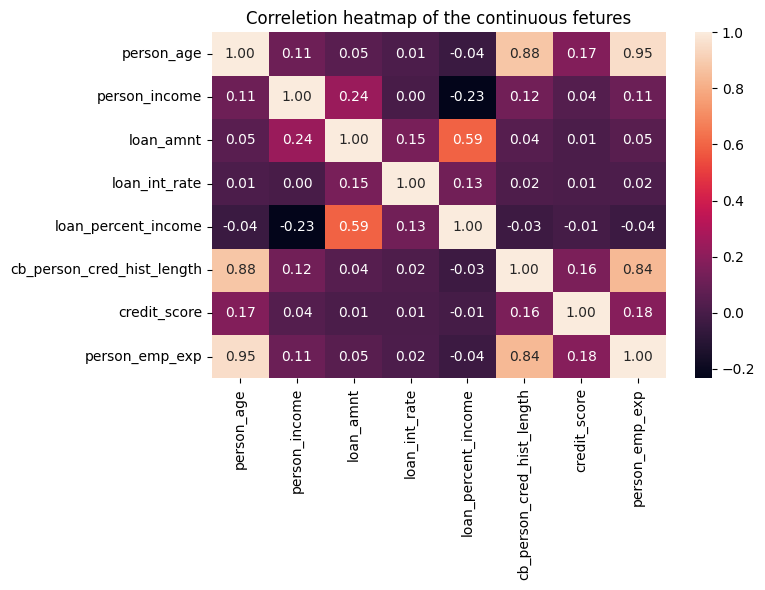

In [149]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[continuous_cols].corr(), annot=True, fmt='.2f')
plt.title('Correletion heatmap of the continuous fetures')
plt.tight_layout()
plt.show()


There is a strong correlation between a borrower's age, credit history length, and employment experience which is expected, as older individuals tend to have worked longer and built up more credit history overtime. We also observe a moderate correlation between loan amount and the loan-to-income ratio, which makes sense since larger loans typically take up a bigger portion of one's income.

# Preprocessing Pipeline

In [150]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [151]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [152]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [153]:
model_categorical_cols = [col for col in categorical_cols if col != 'loan_status']
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, continuous_cols),
    ('cat', categorical_transformer, model_categorical_cols)
], remainder='drop')

In [154]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [155]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    )


In [156]:
NUMERIC_FEATURES = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score"
    
]

CATEGORICAL_FEATURES = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file",
]

TARGET_COLUMN = "loan_status"

MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

In [157]:
X = df[MODEL_FEATURES].copy()
y = df[TARGET_COLUMN].astype(int)

In [158]:
y

0        1
1        0
2        1
3        1
4        1
        ..
44995    1
44996    1
44997    1
44998    1
44999    1
Name: loan_status, Length: 45000, dtype: int64

In [159]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10, stratify=y)
print("Train size : ", X_train.shape)
print("Test size : ", X_test.shape)

Train size :  (36000, 13)
Test size :  (9000, 13)


In [160]:
y_train

3858     1
27867    0
11029    0
32459    0
36743    0
        ..
22264    0
12047    0
26976    1
24523    0
30571    0
Name: loan_status, Length: 36000, dtype: int64

In [161]:
model_pipelines = {
    'LogisticRegression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=10))
    ]),
    'KNeighborsClassifier': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=7))
    ]),
    'RandomForestClassifier': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=10, n_jobs=-1))
    ]),
    'XGBClassifier': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', XGBClassifier(
            random_state=10,
            eval_metric='logloss',
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            n_jobs=-1
        ))
    ])
}

In [162]:
model_pipelines

{'LogisticRegression': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['person_age',
                                                    'person_income', 'loan_amnt',
                                                    'loan_int_rate',
                                                    'loan_percent_income',
                                                    'cb_person_cred_hist_length',
                                                    'credit_score',
                                                    'person_emp_exp']),
                       

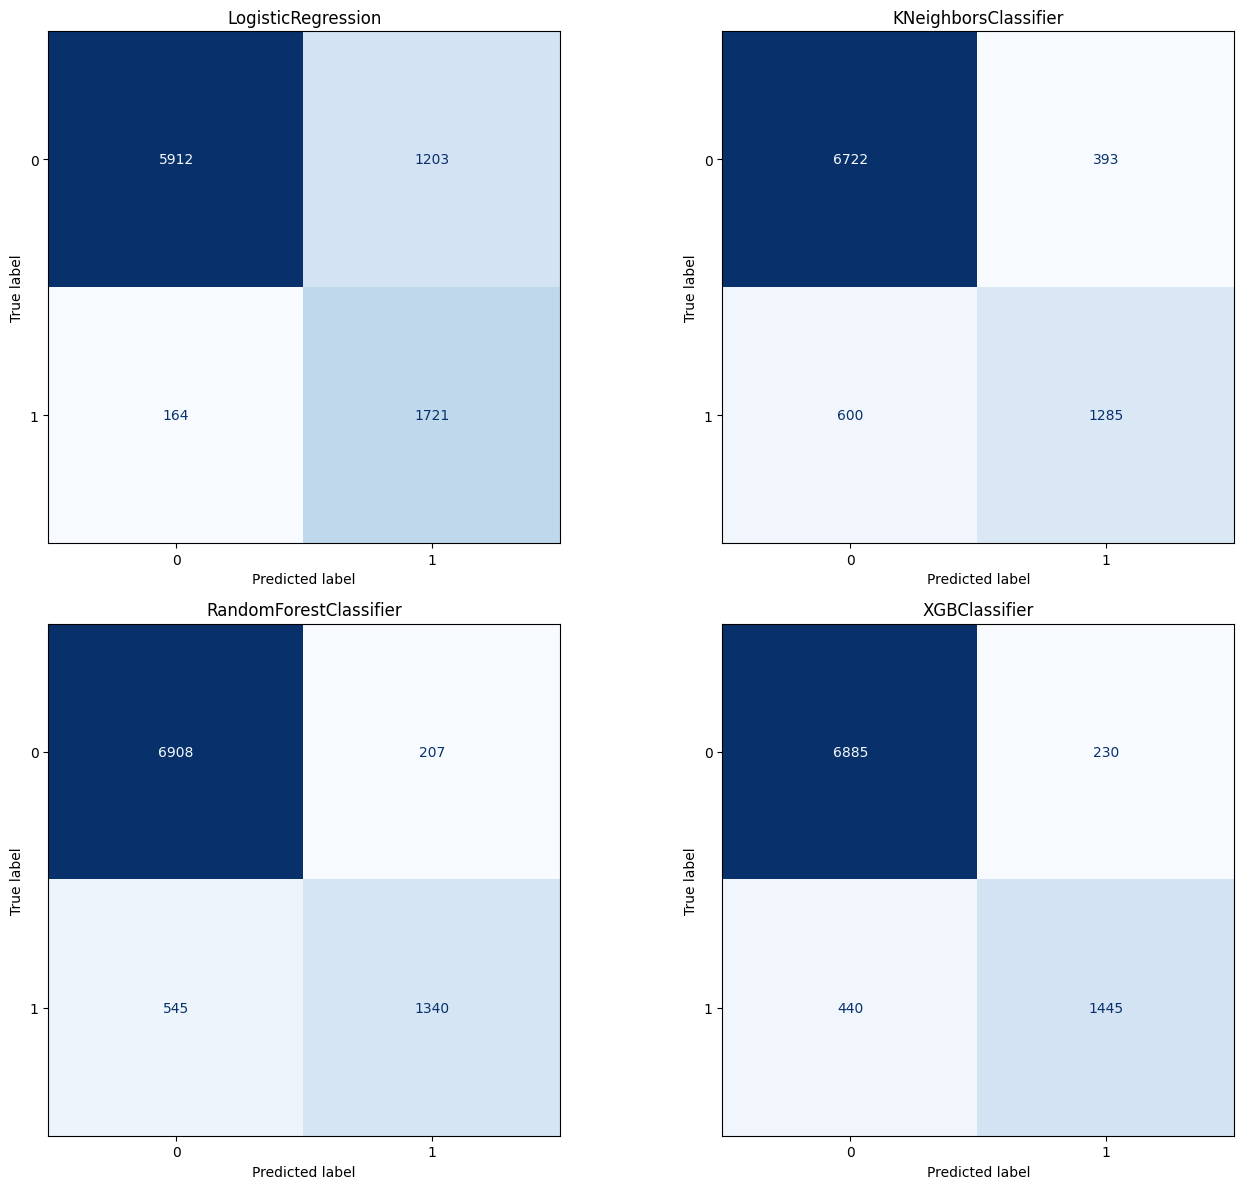


Classification report for LogisticRegression:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90      7115
           1       0.59      0.91      0.72      1885

    accuracy                           0.85      9000
   macro avg       0.78      0.87      0.81      9000
weighted avg       0.89      0.85      0.86      9000


Classification report for KNeighborsClassifier:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      7115
           1       0.77      0.68      0.72      1885

    accuracy                           0.89      9000
   macro avg       0.84      0.81      0.83      9000
weighted avg       0.89      0.89      0.89      9000


Classification report for RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7115
           1       0.87      0.71      0.78      1885

    accuracy                       

,model,accuracy,precision,recall,f1_score
0,XGBClassifier,0.925556,0.862687,0.766578,0.811798
1,RandomForestClassifier,0.916444,0.866193,0.710875,0.780886
2,KNeighborsClassifier,0.889667,0.765793,0.681698,0.721302
3,LogisticRegression,0.848111,0.588577,0.912997,0.715741


In [163]:
results = []
classification_reports = {}
confusion_matrices = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for axis, (model_name, model_pipeline) in zip(axes, model_pipelines.items()):
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)

    results.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0)
    })

    classification_reports[model_name] = classification_report(y_test, y_pred, zero_division=0)
    confusion_matrices[model_name] = confusion_matrix(y_test, y_pred)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        ax=axis,
        cmap='Blues',
        colorbar=False
    )
    axis.set_title(model_name, fontsize=12)

plt.tight_layout()
plt.show()

for model_name, report in classification_reports.items():
    print(f'\nClassification report for {model_name}:')
    print(report)

metrics_df = pd.DataFrame(results).sort_values(
    by=['f1_score', 'recall', 'accuracy'],
    ascending=False
).reset_index(drop=True)

metrics_df

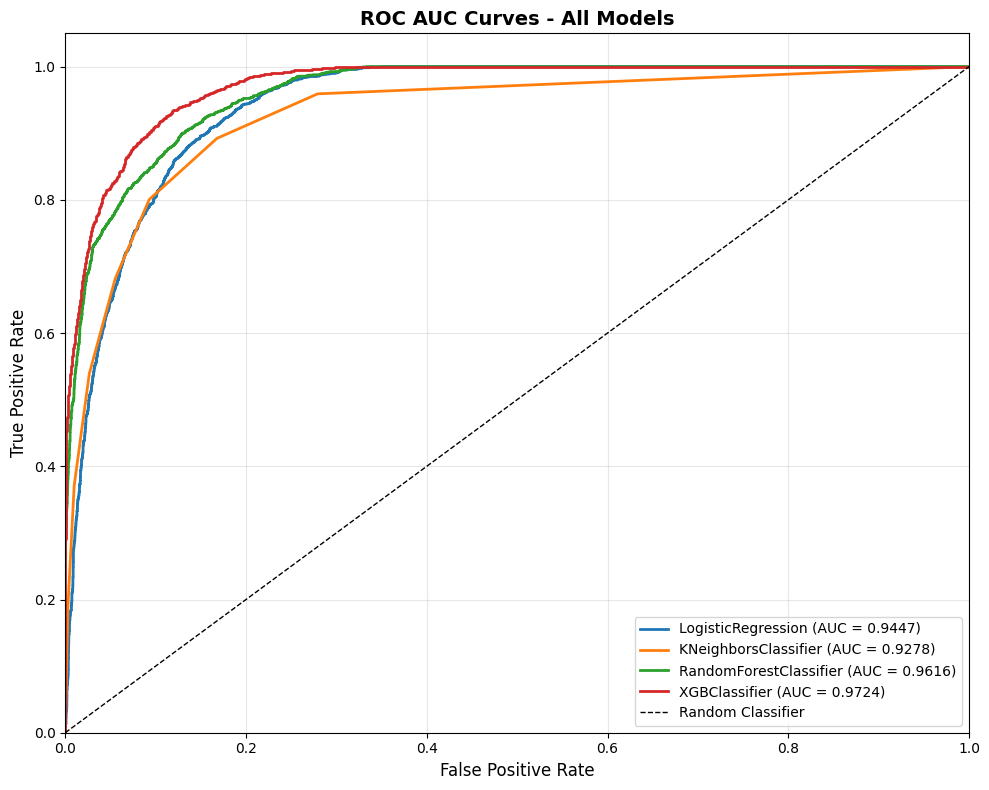


ROC AUC SCORES
XGBClassifier................. 0.9724
RandomForestClassifier........ 0.9616
LogisticRegression............ 0.9447
KNeighborsClassifier.......... 0.9278

Best Model (based on AUC): XGBClassifier
AUC Score: 0.9724


In [164]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

plt.figure(figsize=(10, 8))

auc_scores = {}

for model_name, model_pipeline in model_pipelines.items():
    y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    auc_scores[model_name] = roc_auc
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC AUC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\n' + '='*50)
print('ROC AUC SCORES')
print('='*50)
for model_name, auc_score in sorted(auc_scores.items(), key=lambda x: x[1], reverse=True):
    print(f'{model_name:.<30} {auc_score:.4f}')

best_model_auc = max(auc_scores, key=auc_scores.get)
print('='*50)
print(f'\nBest Model (based on AUC): {best_model_auc}')
print(f'AUC Score: {auc_scores[best_model_auc]:.4f}')
print('='*50)

## DEMOGRAPHIC ANALYSIS OF LOAN APPROVAL PREDICTIONS

In [165]:
# Get predictions from the best model (XGBClassifier)
best_xgb_pipeline = model_pipelines['XGBClassifier']
y_pred_xgb = best_xgb_pipeline.predict(X_test)
y_pred_proba_xgb = best_xgb_pipeline.predict_proba(X_test)[:, 1]

# Create a results dataframe with predictions and demographics
# Get the indices of test set to access original data
test_indices = X_test.index
test_data_with_preds = X_test.copy()
test_data_with_preds['actual_default'] = y_test.values
test_data_with_preds['predicted_default'] = y_pred_xgb
test_data_with_preds['prediction_proba'] = y_pred_proba_xgb

# Get original demographic information from df
test_data_with_preds['person_gender'] = df.loc[test_indices, 'person_gender'].values
test_data_with_preds['person_education'] = df.loc[test_indices, 'person_education'].values
test_data_with_preds['person_home_ownership'] = df.loc[test_indices, 'person_home_ownership'].values

print('\n' + '='*80)
print('DEMOGRAPHIC ANALYSIS OF LOAN APPROVAL PREDICTIONS')
print('='*80)

# Function to calculate approval rates
def calculate_approval_rates(df, group_col):
    approval_rates = df.groupby(group_col)['predicted_default'].apply(
        lambda x: (1 - x.mean()) * 100  # Approval rate = 1 - default rate
    ).sort_values(ascending=False)
    return approval_rates

# 1. GENDER ANALYSIS
print('\n1. GENDER ANALYSIS')
print('-' * 80)
gender_approval = calculate_approval_rates(test_data_with_preds, 'person_gender')
for gender, rate in gender_approval.items():
    count = len(test_data_with_preds[test_data_with_preds['person_gender'] == gender])
    print(f'{gender:.<20} Approval Rate: {rate:>6.2f}% (n={count})')

# 2. EDUCATION LEVEL ANALYSIS
print('\n2. EDUCATION LEVEL ANALYSIS')
print('-' * 80)
education_approval = calculate_approval_rates(test_data_with_preds, 'person_education')
for education, rate in education_approval.items():
    count = len(test_data_with_preds[test_data_with_preds['person_education'] == education])
    print(f'{education:.<30} Approval Rate: {rate:>6.2f}% (n={count})')

# 3. HOME OWNERSHIP ANALYSIS
print('\n3. HOME OWNERSHIP ANALYSIS')
print('-' * 80)
home_approval = calculate_approval_rates(test_data_with_preds, 'person_home_ownership')
for home, rate in home_approval.items():
    count = len(test_data_with_preds[test_data_with_preds['person_home_ownership'] == home])
    print(f'{home:.<30} Approval Rate: {rate:>6.2f}% (n={count})')

# Identify groups with highest and lowest approval rates
print('\n' + '='*80)
print('SUMMARY: HIGHEST AND LOWEST APPROVAL RATES')
print('='*80)
print(f'\nGender - Highest: {gender_approval.index[0]} ({gender_approval.iloc[0]:.2f}%)')
print(f'Gender - Lowest: {gender_approval.index[-1]} ({gender_approval.iloc[-1]:.2f}%)')
print(f'\nEducation - Highest: {education_approval.index[0]} ({education_approval.iloc[0]:.2f}%)')
print(f'Education - Lowest: {education_approval.index[-1]} ({education_approval.iloc[-1]:.2f}%)')
print(f'\nHome Ownership - Highest: {home_approval.index[0]} ({home_approval.iloc[0]:.2f}%)')
print(f'Home Ownership - Lowest: {home_approval.index[-1]} ({home_approval.iloc[-1]:.2f}%)')


DEMOGRAPHIC ANALYSIS OF LOAN APPROVAL PREDICTIONS

1. GENDER ANALYSIS
--------------------------------------------------------------------------------
female.............. Approval Rate:  82.20% (n=3927)
male................ Approval Rate:  80.76% (n=5073)

2. EDUCATION LEVEL ANALYSIS
--------------------------------------------------------------------------------
Doctorate..................... Approval Rate:  83.61% (n=122)
Master........................ Approval Rate:  82.36% (n=1406)
Associate..................... Approval Rate:  81.72% (n=2423)
High School................... Approval Rate:  81.39% (n=2359)
Bachelor...................... Approval Rate:  80.48% (n=2690)

3. HOME OWNERSHIP ANALYSIS
--------------------------------------------------------------------------------
OWN........................... Approval Rate:  94.03% (n=586)
MORTGAGE...................... Approval Rate:  92.89% (n=3673)
OTHER......................... Approval Rate:  76.00% (n=25)
RENT...................


ROC CURVES BY DEMOGRAPHIC GROUP


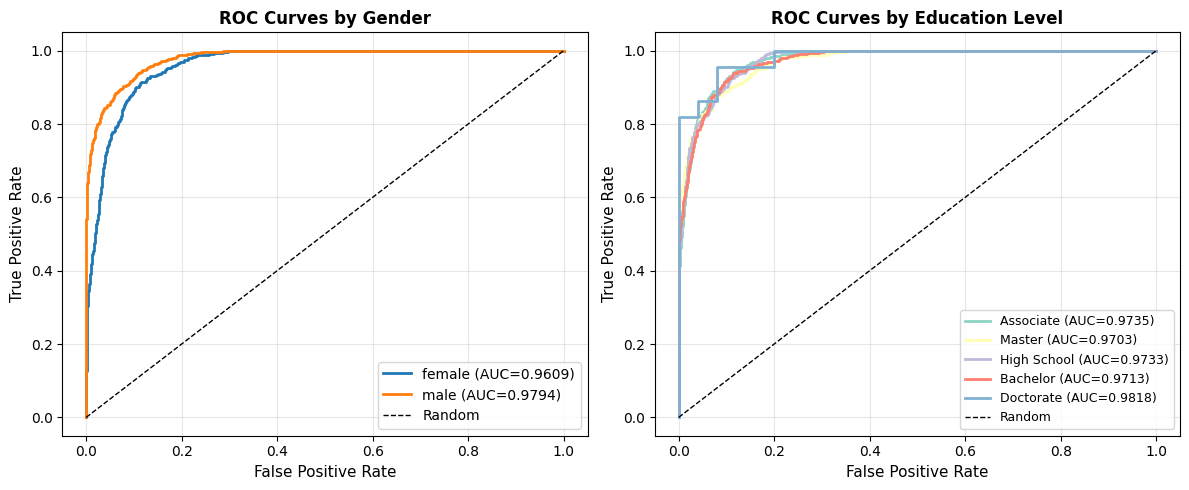

In [166]:


# ROC CURVES BY DEMOGRAPHIC GROUP
print('\n' + '='*80)
print('ROC CURVES BY DEMOGRAPHIC GROUP')
print('='*80)

# Gender-wise ROC curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for gender in test_data_with_preds['person_gender'].unique():
    mask = test_data_with_preds['person_gender'] == gender
    fpr_gender, tpr_gender, _ = roc_curve(
        test_data_with_preds[mask]['actual_default'],
        test_data_with_preds[mask]['prediction_proba']
    )
    roc_auc_gender = auc(fpr_gender, tpr_gender)
    plt.plot(fpr_gender, tpr_gender, label=f'{gender} (AUC={roc_auc_gender:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves by Gender', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

# Education-wise ROC curves
plt.subplot(1, 2, 2)
colors_edu = plt.cm.Set3(range(len(test_data_with_preds['person_education'].unique())))
for i, education in enumerate(test_data_with_preds['person_education'].unique()):
    mask = test_data_with_preds['person_education'] == education
    fpr_edu, tpr_edu, _ = roc_curve(
        test_data_with_preds[mask]['actual_default'],
        test_data_with_preds[mask]['prediction_proba']
    )
    roc_auc_edu = auc(fpr_edu, tpr_edu)
    plt.plot(fpr_edu, tpr_edu, label=f'{education} (AUC={roc_auc_edu:.4f})', linewidth=2, color=colors_edu[i])

plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves by Education Level', fontsize=12, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [167]:
# Compact subgroup ROC-AUC summary for interview notes
gender_auc_summary = {}
for gender in test_data_with_preds['person_gender'].unique():
    mask = test_data_with_preds['person_gender'] == gender
    fpr_gender, tpr_gender, _ = roc_curve(
        test_data_with_preds.loc[mask, 'actual_default'],
        test_data_with_preds.loc[mask, 'prediction_proba']
    )
    gender_auc_summary[gender] = auc(fpr_gender, tpr_gender)

education_auc_summary = {}
for education in test_data_with_preds['person_education'].unique():
    mask = test_data_with_preds['person_education'] == education
    fpr_edu, tpr_edu, _ = roc_curve(
        test_data_with_preds.loc[mask, 'actual_default'],
        test_data_with_preds.loc[mask, 'prediction_proba']
    )
    education_auc_summary[education] = auc(fpr_edu, tpr_edu)

print('Gender AUCs:')
for group, score in sorted(gender_auc_summary.items(), key=lambda x: x[1], reverse=True):
    print(f'  {group}: {score:.4f}')

print('\nEducation AUCs:')
for group, score in sorted(education_auc_summary.items(), key=lambda x: x[1], reverse=True):
    print(f'  {group}: {score:.4f}')

Gender AUCs:
  male: 0.9794
  female: 0.9609

Education AUCs:
  Doctorate: 0.9818
  Associate: 0.9735
  High School: 0.9733
  Bachelor: 0.9713
  Master: 0.9703


In [168]:
from scipy.stats import chi2_contingency

# GENDER BIAS TESTING
print('\n' + '='*80)
print('GENDER BIAS ANALYSIS - CHI-SQUARE TEST')
print('='*80)
# Create contingency table: Gender vs Prediction
contingency = pd.crosstab(
    test_data_with_preds['person_gender'],
    test_data_with_preds['predicted_default']
)
chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f'\nContingency Table (Gender vs Approval Decision):')
print(contingency)
print(f'\nChi-square test results:')
print(f'  Chi-square statistic: {chi2:.4f}')
print(f'  P-value: {p_value:.4f}')
print(f'  Degrees of freedom: {dof}')

if p_value < 0.05:
    print(f'\nRESULT: SIGNIFICANT GENDER BIAS DETECTED (p < 0.05)')
    print(f'   The approval rates between genders are statistically significantly different.')
else:
    print(f'\nRESULT: No significant gender bias detected (p >= 0.05)')
    print(f'   The approval rates between genders are not statistically significantly different.')

# Calculate disparate impact ratio
print('\n' + '='*80)
print('DISPARATE IMPACT ANALYSIS')
print('='*80)

genders = test_data_with_preds['person_gender'].unique()
approval_rates_dict = {}
for gender in genders:
    mask = test_data_with_preds['person_gender'] == gender
    approval_rate = (1 - test_data_with_preds[mask]['predicted_default'].mean()) * 100
    approval_rates_dict[gender] = approval_rate

sorted_rates = sorted(approval_rates_dict.items(), key=lambda x: x[1], reverse=True)
highest_group, highest_rate = sorted_rates[0]
lowest_group, lowest_rate = sorted_rates[1]

disparate_impact = (lowest_rate / highest_rate) * 100

print(f'\nHighest approval rate: {highest_group} ({highest_rate:.2f}%)')
print(f'Lowest approval rate: {lowest_group} ({lowest_rate:.2f}%)')
print(f'Disparate Impact Ratio: {disparate_impact:.2f}%')

if disparate_impact >= 80:
    print(f'\nRESULT: No disparate impact (Rule of 80% satisfied)')
    print(f'   The lowest approval rate is at least 80% of the highest rate.')
else:
    print(f'\nRESULT: POTENTIAL DISPARATE IMPACT DETECTED (< 80%)')
    print(f'   The lowest approval rate is less than 80% of the highest rate.')
    print(f'   This may indicate discriminatory impact on the protected class.')


GENDER BIAS ANALYSIS - CHI-SQUARE TEST

Contingency Table (Gender vs Approval Decision):
predicted_default     0    1
person_gender               
female             3228  699
male               4097  976

Chi-square test results:
  Chi-square statistic: 2.9328
  P-value: 0.0868
  Degrees of freedom: 1

RESULT: No significant gender bias detected (p >= 0.05)
   The approval rates between genders are not statistically significantly different.

DISPARATE IMPACT ANALYSIS

Highest approval rate: female (82.20%)
Lowest approval rate: male (80.76%)
Disparate Impact Ratio: 98.25%

RESULT: No disparate impact (Rule of 80% satisfied)
   The lowest approval rate is at least 80% of the highest rate.
